In [8]:
!nvidia-smi

Sun Sep 14 16:55:35 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [29]:
# --- Setup / imports ---
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    precision_score, recall_score, f1_score, balanced_accuracy_score
)

In [30]:
# --- Load participants (ensure strings for ID matching) ---
dataParticipants = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Autism/participants.csv')
X_Participants = dataParticipants["ParticipantID"].astype(str).values
y_Participants = dataParticipants["Label"].values  # 0/1 at participant level

In [31]:
# --- Load embeddings NPZ ---
dataset = np.load('/content/ASD_vgg16.npz', allow_pickle=True)
X   = dataset['X'].astype('float32')
y   = dataset['y'].astype('int32')
IDs = dataset['IDs'].astype(str)   # make sure same dtype as X_Participants

print("Shapes -> X:", X.shape, "y:", y.shape, "unique IDs:", len(np.unique(IDs)))

Shapes -> X: (3282, 512) y: (3282,) unique IDs: 54


In [33]:
# --- CV config ---
folds   = 3
nEpochs = 20
nBatch  = 32
randState = 1

kfold = StratifiedKFold(n_splits=folds, shuffle=True, random_state=randState).split(X_Participants, y_Participants)

In [34]:
# --- Tracking ---
tprs, aucs = [], []
recalls, precisions, f1s, bals = [], [], [], []
mean_fpr = np.linspace(0, 1, 100)

start = time.time()
for fold, (train_idx, test_idx) in enumerate(kfold, 1):
    train_p = X_Participants[train_idx]
    test_p  = X_Participants[test_idx]

    # masks on image-level
    indexTrain = np.isin(IDs, train_p)
    indexTest  = np.isin(IDs, test_p)

    X_train, y_train = X[indexTrain], y[indexTrain]
    X_test,  y_test  = X[indexTest],  y[indexTest]

    print(f"\nFold {fold} — train n={len(y_train)}, test n={len(y_test)}")

    # guard: empty test fold
    if X_test.shape[0] == 0:
        print("Test set is empty for this fold — skipping.")
        continue

    # build simple MLP
    model = Sequential([
        Dense(256, activation='relu', input_shape=(X.shape[1],)),
        Dense(128, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    # fit
    model.fit(X_train, y_train, validation_split=0.2, epochs=nEpochs, batch_size=nBatch, verbose=1)

    # predict
    p_test = model.predict(X_test, verbose=0).ravel()
    y_pred = (p_test >= 0.5).astype(int)

    # precision/recall/f1/balanced acc at 0.5 threshold
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    bal  = balanced_accuracy_score(y_test, y_pred)

    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)
    bals.append(bal)

    # ROC metrics (only if both classes present)
    if len(np.unique(y_test)) > 1:
        fpr, tpr, _ = roc_curve(y_test, p_test)
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        print(f"AUC={roc_auc:.3f} | Precision={prec:.3f} | Recall={rec:.3f} | F1={f1:.3f} | BalAcc={bal:.3f}")
    else:
        print(f"AUC=n/a (single class in test) | Precision={prec:.3f} | Recall={rec:.3f} | F1={f1:.3f} | BalAcc={bal:.3f}")

end = time.time()



Fold 1 — train n=1824, test n=954
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6596 - loss: 1.0760 - val_accuracy: 0.7534 - val_loss: 0.5229
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8268 - loss: 0.4021 - val_accuracy: 0.7589 - val_loss: 0.5149
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8604 - loss: 0.3044 - val_accuracy: 0.8411 - val_loss: 0.3821
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9248 - loss: 0.2116 - val_accuracy: 0.8603 - val_loss: 0.3163
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9705 - loss: 0.1210 - val_accuracy: 0.8795 - val_loss: 0.2817
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9648 - loss: 0.0878 - val_accuracy: 0.8959 - val_loss: 0.2309
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9865 - loss: 0.0590 - val_accuracy: 0.8630 - val_loss: 0.2570
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9928 - loss: 0.0331 - val_accuracy: 0.9068 - val_loss: 0.2265
Ep

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.7544 - loss: 0.5729 - val_accuracy: 0.8048 - val_loss: 0.4515
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8839 - loss: 0.3069 - val_accuracy: 0.8449 - val_loss: 0.3815
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9140 - loss: 0.2213 - val_accuracy: 0.8610 - val_loss: 0.3235
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9638 - loss: 0.1226 - val_accuracy: 0.9037 - val_loss: 0.2792
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9893 - loss: 0.0636 - val_accuracy: 0.8877 - val_loss: 0.2688
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9928 - loss: 0.0440 - val_accuracy: 0.8770 - val_loss: 0.2897
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9917 - loss: 0.0275 - val_accuracy: 0.9198 - val_loss: 0.2113
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0098 - val_accuracy: 0.9278 - val_loss: 0.2147
Ep

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.7773 - loss: 0.5528 - val_accuracy: 0.7567 - val_loss: 0.5057
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9165 - loss: 0.2181 - val_accuracy: 0.8529 - val_loss: 0.3690
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9429 - loss: 0.1483 - val_accuracy: 0.8930 - val_loss: 0.2790
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9839 - loss: 0.0595 - val_accuracy: 0.9144 - val_loss: 0.2328
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9724 - loss: 0.0577 - val_accuracy: 0.8690 - val_loss: 0.2994
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9996 - loss: 0.0164 - val_accuracy: 0.8155 - val_loss: 0.4212
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9966 - loss: 0.0250 - val_accuracy: 0.8396 - val_loss: 0.3543
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0128 - val_accuracy: 0.8930 - val_loss: 0.2401
Ep


== Mean (±SD) over folds ==
AUROC  : 0.791 ± 0.053
AUPRC  : (compute separately if needed)
Precision : 0.681 ± 0.053
Recall    : 0.546 ± 0.137
F1        : 0.597 ± 0.099
BalAcc    : 0.723 ± 0.067
Training Time: 28.52 seconds.


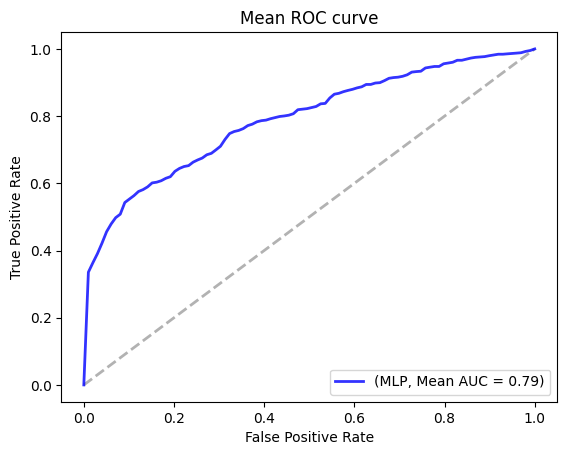

In [35]:
# --- Summaries ---
print("\n== Mean (±SD) over folds ==")
if aucs:
    print(f"AUROC  : {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
else:
    print("AUROC  : n/a (all folds single-class)")
print(f"AUPRC  : (compute separately if needed)")
print(f"Precision : {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
print(f"Recall    : {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
print(f"F1        : {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
print(f"BalAcc    : {np.mean(bals):.3f} ± {np.std(bals):.3f}")
print("Training Time:", round(end - start, 2), "seconds.")

# --- Mean ROC curve (only if we computed any) ---
plt.figure()
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='black', alpha=0.3)
if tprs:
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    plt.plot(mean_fpr, mean_tpr, color='blue',
             label=r'(MLP, Mean AUC = %0.2f)' % (mean_auc),
             lw=2, alpha=.8)
    plt.legend(loc="lower right")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('Mean ROC curve')
plt.show()